# Relationships in Data

This notebook focuses on the interplay between the columns in the dataset.

In [2]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# load data into datframe
df = pd.read_csv("../datasets/Effectiveness_Exam_To_Sleep_Quality.csv")
df.head()

,age,gender,course,study_hours,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,yes,9.8,poor,coaching,low,moderate,43.7


**Does studying longer have an impact on exam scores?**

To check if there's a relationship between the two columns, I'll be using the inbuilt `corr()` method, that calculates the Pearson's Correlation Coefficient.

In [4]:
df['study_hours'].corr(df['exam_score'])

np.float64(0.7177879939079734)

It appears that there is a postive correlation between the amount of time spent studying and the exam score.

Let's visualize this.

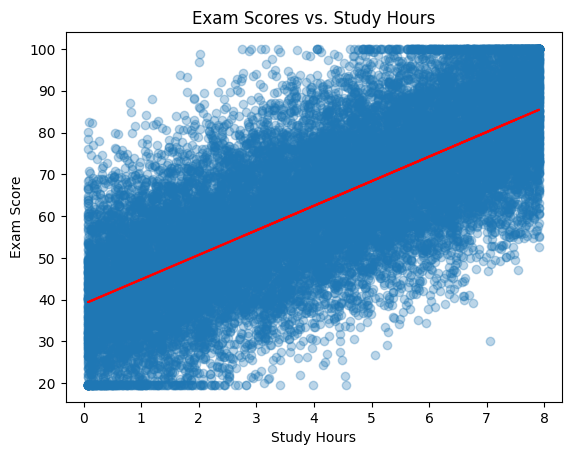

In [5]:
slope, intercept = np.polyfit(x=df['study_hours'], y=df['exam_score'], deg=1)
line = slope * df['study_hours'] + intercept

plt.scatter(x=df['study_hours'], y=df['exam_score'], alpha=0.3)
plt.plot(df['study_hours'], line, color='red')

# add labels
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Exam Scores vs. Study Hours')

plt.show()

From the chart, it appears that there is a positive relationship between study hours and exam scores, though there is significant variability. Many scores cluster around the max exam score(100), showing that there is possibly a [ceiling effect ](https://www.researchprospect.com/what-is-a-ceiling-effect/) where students that are high performing cannot be distinguished from one another.

Meaning we don't know if the student that studied for 5 hours and got a 100 was better prepared than the student that studied for 8 hours and got a 100.

**Which has a stronger relationship with exam scores: study hours, sleep quality, or sleep hours?**


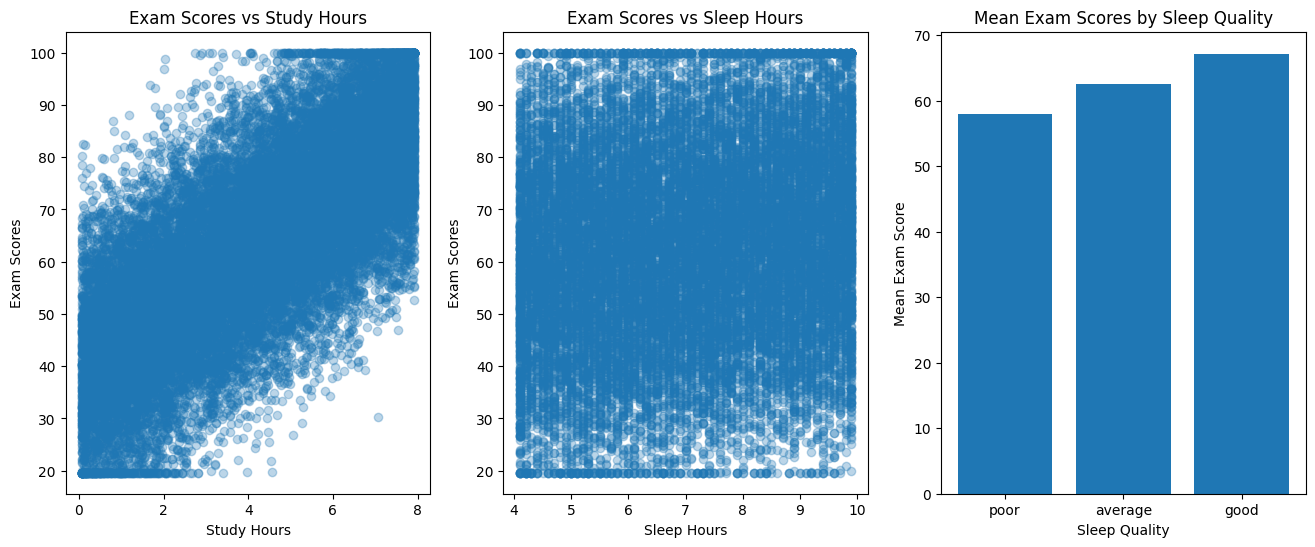

In [39]:
sleep_exam = df.groupby('sleep_quality')['exam_score'].mean().sort_values()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16,6))

ax1.scatter(x=df['study_hours'], y=df['exam_score'], alpha=0.3)
ax2.scatter(x=df['sleep_hours'], y=df['exam_score'], alpha=0.3)
ax3.bar(x=sleep_exam.index, height=sleep_exam.values)

ax1.set_title('Exam Scores vs Study Hours')
ax1.set_xlabel('Study Hours')
ax1.set_ylabel('Exam Scores')

ax2.set_title('Exam Scores vs Sleep Hours')
ax2.set_xlabel('Sleep Hours')
ax2.set_ylabel('Exam Scores')

ax3.set_title('Mean Exam Scores by Sleep Quality')
ax3.set_xlabel('Sleep Quality')
ax3.set_ylabel('Mean Exam Score')


plt.show()

From the plot, **study hours** show a clear positive relationship with exam scores. **Sleep quality** also shows a gradual increase in average scores, suggesting a possible influence, although the effect appears smaller. In contrast, **sleep duration** does not display a clear relationship with exam performance.

We have our winner!!! 

Studying longer may have more of an effect on exam performance that sleep duration and sleep quality. And quality might be more important that quantity!